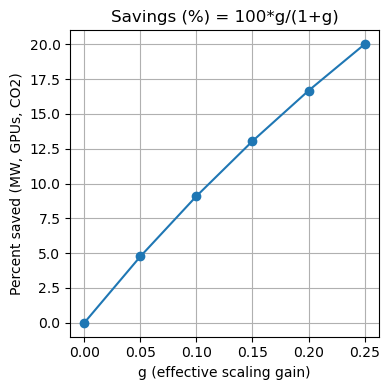

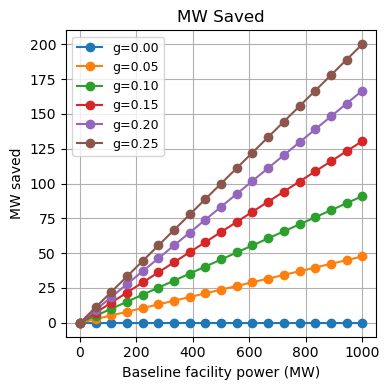

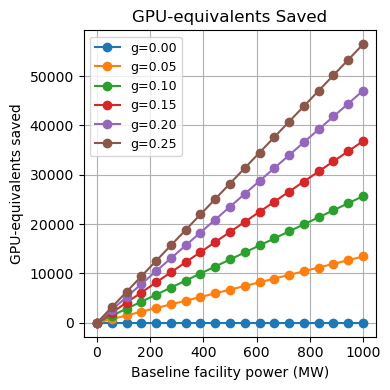

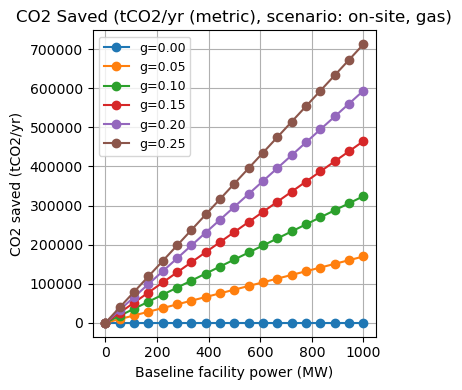

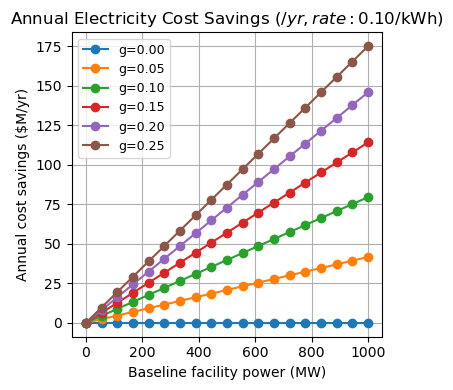

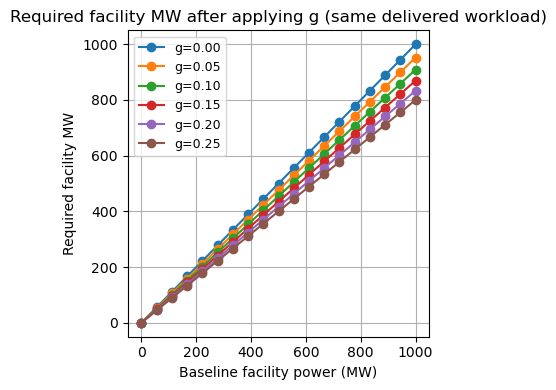

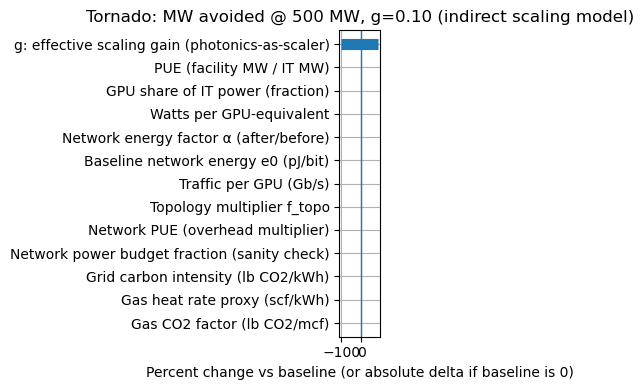

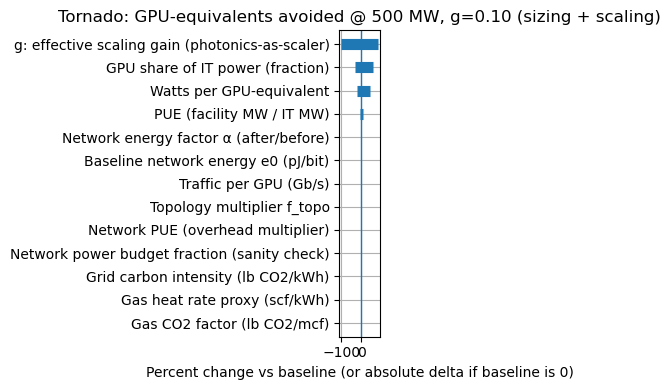

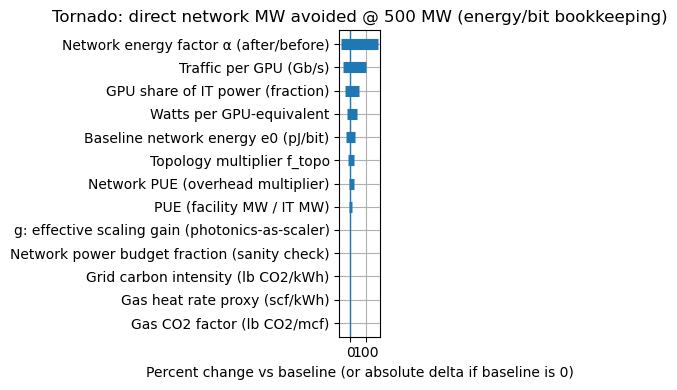

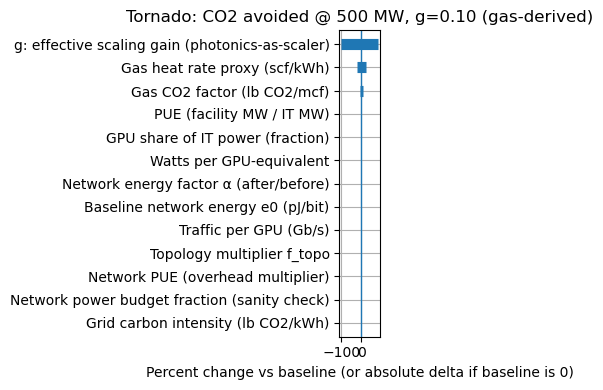

==== Tier-0 Baseline-Free + Facility Sweep + Tornado (no CLI) ====
Saved% formula: saved_fraction = g/(1+g)
Wrote: /home/bkiefer/outputs/g_percent_savings.csv
Wrote: /home/bkiefer/outputs/plot_g_percent_saved.png
Wrote: /home/bkiefer/outputs/facility_sweep_savings.csv
Wrote: /home/bkiefer/outputs/plot_MW_saved_vs_facilityMW.png
Wrote: /home/bkiefer/outputs/plot_GPU_saved_vs_facilityMW.png
Wrote: /home/bkiefer/outputs/plot_CO2_saved_vs_facilityMW.png
Wrote: /home/bkiefer/outputs/plot_cost_saved_vs_facilityMW.png
Wrote: /home/bkiefer/outputs/plot_facilityMW_after_vs_facilityMW.png
Wrote: /home/bkiefer/outputs/sensitivity_tornado.csv
Wrote: /home/bkiefer/outputs/plot_tornado_MW_saved.png
Wrote: /home/bkiefer/outputs/plot_tornado_GPU_saved.png
Wrote: /home/bkiefer/outputs/plot_tornado_direct_network_MW_saved.png
Wrote: /home/bkiefer/outputs/plot_tornado_CO2_saved.png
CO2 factors (lb/kWh): grid=0.810, gas-derived=0.897 (selected=gas)
Electricity cost: $0.10/kWh


In [4]:
#!/usr/bin/env python3
# tier0_end2end.py
"""
Tier-0 (No CLI): baseline-free percent savings from g + facility-MW sweep plots + tornado sensitivity.

v14 update:
- Added annual electricity cost savings calculation and plot
- Cost savings based on $/kWh electricity rate
- Maintains all existing functionality and plot styles

Edit the "USER-EDITABLE DEFAULTS (NO CLI)" block. No command-line arguments.
"""

from __future__ import annotations

import csv
from dataclasses import dataclass
from pathlib import Path
from typing import List, Dict, Tuple

import matplotlib.pyplot as plt

# =============================================================================
# USER-EDITABLE DEFAULTS (NO CLI)
# =============================================================================
out_outdir = "outputs"
out_show_plots = True               # True = show plots on screen (also saves PNG)
out_fig_square_inches = 4.0          # all plots square

# Facility MW sweep (baseline facility power per building)
dc_sweep_facility_mw_min = 0.0
dc_sweep_facility_mw_max = 1000.0
dc_sweep_npoints = 19                # number of points in the sweep (>=2)

# Photonics-as-scaler scenarios (effective scaling gain)
dc_indirect_g_scenarios = [0.00, 0.05, 0.10, 0.15, 0.20, 0.25]

# CO2 intensity choice for sweep plots
# - "gas": uses derived gas CO2 factor from heat-rate proxy
# - "grid": uses ex_grid_avg_lb_co2_per_kwh
ex_co2_plot_factor = "gas"           # "gas" or "grid"
ex_grid_avg_lb_co2_per_kwh = 0.81
ex_ng_cuft_per_kwh_electricity = 7.42
ex_ng_lb_co2_per_mcf = 120.85

# Electricity cost assumptions
ex_electricity_cost_per_kwh = 0.10  # $/kWh - typical industrial data center rate

# Datacenter sizing assumptions (used for GPU sizing + GPU sweep + GPU tornado)
dc_site_pue_for_sizing = 1.25
dc_it_frac_gpu_equiv = 0.45
dc_w_per_gpu_equiv = 1275.0

# Networking assumptions (used for "direct network MW" bookkeeping + tornado)
dc_frac_net_of_facility = 0.05       # sanity budget (does not affect direct network MW saved)
dc_net_e0_pj_per_bit = 6.0
dc_net_alpha = 0.75
dc_net_r_gbps_per_gpu = 40.0
dc_net_ftopo = 1.3
dc_net_pue_net = 1.25

# Sensitivity (tornado) baseline point
dc_sens_baseline_facility_mw = 500.0
dc_sens_g = 0.10

# OAT bounds (parameter, low, high)
dc_sens_bounds = [
    ("dc_sens_g", 0.00, 0.20),

    ("dc_site_pue_for_sizing", 1.15, 1.35),
    ("dc_it_frac_gpu_equiv", 0.30, 0.70),
    ("dc_w_per_gpu_equiv", 900.0, 1600.0),

    ("dc_net_alpha", 0.30, 0.90),
    ("dc_net_e0_pj_per_bit", 6.0 * 0.7, 6.0 * 1.3),
    ("dc_net_r_gbps_per_gpu", 20.0, 80.0),
    ("dc_net_ftopo", 1.1, 1.6),
    ("dc_net_pue_net", 1.10, 1.56),
    ("dc_frac_net_of_facility", 0.03, 0.10),  # budget sanity lever (expected ~0 impact)

    ("ex_grid_avg_lb_co2_per_kwh", 0.50, 1.10),
    ("ex_ng_cuft_per_kwh_electricity", 6.0, 9.0),
    ("ex_ng_lb_co2_per_mcf", 110.0, 130.0),
]
# =============================================================================


def fig_square() -> Tuple[float, float]:
    s = float(out_fig_square_inches)
    return (s, s)


def write_csv(path: Path, header: List[str], rows: List[List[object]]) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", newline="") as f:
        w = csv.writer(f)
        w.writerow(header)
        w.writerows(rows)


def save_and_maybe_show(path: Path) -> None:
    plt.tight_layout()
    plt.savefig(path, dpi=200, bbox_inches="tight")
    if out_show_plots:
        plt.show()
    plt.close()


def add_grid() -> None:
    plt.grid(True)


# -----------------------------------------------------------------------------
# Tier-0 g model: baseline-free savings fractions
# -----------------------------------------------------------------------------
def remaining_fraction(g: float) -> float:
    return 1.0 / (1.0 + max(0.0, float(g)))


def saved_fraction(g: float) -> float:
    return 1.0 - remaining_fraction(g)


def make_g_percent_table(outdir: Path) -> None:
    gs = [float(x) for x in dc_indirect_g_scenarios]
    rows = []
    for g in gs:
        rem = remaining_fraction(g)
        sav = 1.0 - rem
        rows.append([g, rem, 100.0 * rem, sav, 100.0 * sav])

    write_csv(
        outdir / "g_percent_savings.csv",
        header=["g", "remaining_fraction", "remaining_percent", "saved_fraction", "saved_percent"],
        rows=rows,
    )

    plt.figure(figsize=fig_square())
    plt.plot(gs, [100.0 * saved_fraction(g) for g in gs], marker="o")
    plt.xlabel("g (effective scaling gain)")
    plt.ylabel("Percent saved (MW, GPUs, CO2)")
    plt.title("Savings (%) = 100*g/(1+g)")
    add_grid()
    save_and_maybe_show(outdir / "plot_g_percent_saved.png")


# -----------------------------------------------------------------------------
# Supporting models for sweeps + tornado (GPU sizing, CO2, Cost)
# -----------------------------------------------------------------------------
def ex_ng_lb_co2_per_kwh(ng_cuft_per_kwh: float, ng_lb_co2_per_mcf: float) -> float:
    return ng_cuft_per_kwh * ng_lb_co2_per_mcf / 1000.0


def co2_tonnes_per_year_from_mw(avg_mw: float, lb_per_kwh: float) -> float:
    kwh = avg_mw * 1000.0 * 8760.0
    lb = kwh * lb_per_kwh
    return lb / 2204.6226218


def cost_saved_per_year_from_mw(mw_saved: float, cost_per_kwh: float) -> float:
    """
    Calculate annual electricity cost savings.
    
    Args:
        mw_saved: Power savings in MW
        cost_per_kwh: Electricity cost in $/kWh
    
    Returns:
        Annual cost savings in $/year
    """
    kwh_per_year = mw_saved * 1000.0 * 8760.0
    return kwh_per_year * cost_per_kwh


def it_mw_from_facility_mw(fac_mw: float, pue: float) -> float:
    return fac_mw / pue


def gpu_equiv_from_it_mw(it_mw: float, it_frac_gpu: float, w_per_gpu: float) -> float:
    return (it_mw * 1e6 * it_frac_gpu) / w_per_gpu


# -----------------------------------------------------------------------------
# Facility MW sweep plots (restored)
# -----------------------------------------------------------------------------
def linspace(a: float, b: float, n: int) -> List[float]:
    if n < 2:
        return [a]
    step = (b - a) / (n - 1)
    return [a + i * step for i in range(n)]


def selected_lbco2() -> float:
    if ex_co2_plot_factor == "grid":
        return float(ex_grid_avg_lb_co2_per_kwh)
    return ex_ng_lb_co2_per_kwh(float(ex_ng_cuft_per_kwh_electricity), float(ex_ng_lb_co2_per_mcf))


def make_facility_sweep_plots(outdir: Path) -> None:
    fac_list = linspace(float(dc_sweep_facility_mw_min), float(dc_sweep_facility_mw_max), int(dc_sweep_npoints))
    gs = [float(x) for x in dc_indirect_g_scenarios]

    lbco2 = selected_lbco2()
    co2_label = "scenario: on-site, gas" if ex_co2_plot_factor == "gas" else "scenario: off-site, gas"

    # Prepare CSV rows
    # For each baseline facility MW and each g, compute:
    # - facility MW after, MW saved
    # - GPU count baseline, GPU after, GPU saved
    # - CO2 baseline, CO2 after, CO2 saved
    # - Annual cost saved
    rows = []
    for fac in fac_list:
        it_mw = it_mw_from_facility_mw(fac, float(dc_site_pue_for_sizing))
        gpu_base = gpu_equiv_from_it_mw(it_mw, float(dc_it_frac_gpu_equiv), float(dc_w_per_gpu_equiv))
        co2_base = co2_tonnes_per_year_from_mw(fac, lbco2)
        for g in gs:
            fac_after = fac * remaining_fraction(g)
            mw_saved = fac - fac_after
            gpu_after = gpu_base * remaining_fraction(g)
            gpu_saved = gpu_base - gpu_after
            co2_after = co2_tonnes_per_year_from_mw(fac_after, lbco2)
            co2_saved = co2_base - co2_after
            cost_saved = cost_saved_per_year_from_mw(mw_saved, float(ex_electricity_cost_per_kwh))
            rows.append([
                fac, g,
                fac_after, mw_saved,
                gpu_base, gpu_after, gpu_saved,
                co2_base, co2_after, co2_saved,
                cost_saved,
            ])

    write_csv(
        outdir / "facility_sweep_savings.csv",
        header=[
            "facility_mw_baseline", "g",
            "facility_mw_after", "facility_mw_saved",
            "gpu_equiv_baseline", "gpu_equiv_after", "gpu_equiv_saved",
            f"co2_tpy_baseline_{co2_label}", f"co2_tpy_after_{co2_label}", f"co2_tpy_saved_{co2_label}",
            "annual_cost_saved_dollars",
        ],
        rows=rows,
    )

    # Helper to plot y vs x for each g
    def plot_metric(out_png: Path, title: str, ylabel: str, y_for_row) -> None:
        plt.figure(figsize=fig_square())
        for g in gs:
            xs = []
            ys = []
            for fac in fac_list:
                # find the row for this fac,g: compute directly (faster/robust)
                it_mw = it_mw_from_facility_mw(fac, float(dc_site_pue_for_sizing))
                gpu_base = gpu_equiv_from_it_mw(it_mw, float(dc_it_frac_gpu_equiv), float(dc_w_per_gpu_equiv))
                co2_base = co2_tonnes_per_year_from_mw(fac, lbco2)
                fac_after = fac * remaining_fraction(g)
                mw_saved = fac - fac_after
                gpu_after = gpu_base * remaining_fraction(g)
                gpu_saved = gpu_base - gpu_after
                co2_after = co2_tonnes_per_year_from_mw(fac_after, lbco2)
                co2_saved = co2_base - co2_after
                cost_saved = cost_saved_per_year_from_mw(mw_saved, float(ex_electricity_cost_per_kwh))
                xs.append(fac)
                ys.append(y_for_row(fac, fac_after, mw_saved, gpu_base, gpu_after, gpu_saved, co2_base, co2_after, co2_saved, cost_saved))
            plt.plot(xs, ys, marker="o", label=f"g={g:.2f}")
        plt.xlabel("Baseline facility power (MW)")
        plt.ylabel(ylabel)
        plt.title(title)
        add_grid()
        plt.legend(loc="best", fontsize=9)
        save_and_maybe_show(out_png)

    # Savings plots (as you requested)
    plot_metric(
        outdir / "plot_MW_saved_vs_facilityMW.png",
        "MW Saved",
        "MW saved",
        lambda fac, fac_after, mw_saved, *_: mw_saved,
    )
    plt.figure(figsize=fig_square()); plt.close()  # ensure no bleed

    plot_metric(
        outdir / "plot_GPU_saved_vs_facilityMW.png",
        "GPU-equivalents Saved",
        "GPU-equivalents saved",
        lambda fac, fac_after, mw_saved, gpu_base, gpu_after, gpu_saved, *_: gpu_saved,
    )
    plt.figure(figsize=fig_square()); plt.close()

    plot_metric(
        outdir / "plot_CO2_saved_vs_facilityMW.png",
        f"CO2 Saved (tCO2/yr (metric), {co2_label})",
        "CO2 saved (tCO2/yr)",
        lambda fac, fac_after, mw_saved, gpu_base, gpu_after, gpu_saved, co2_base, co2_after, co2_saved, *_: co2_saved,
    )
    plt.figure(figsize=fig_square()); plt.close()

    # NEW: Annual cost savings plot
    plot_metric(
        outdir / "plot_cost_saved_vs_facilityMW.png",
        f"Annual Electricity Cost Savings ($/yr, rate: ${ex_electricity_cost_per_kwh:.2f}/kWh)",
        "Annual cost savings ($M/yr)",
        lambda fac, fac_after, mw_saved, gpu_base, gpu_after, gpu_saved, co2_base, co2_after, co2_saved, cost_saved: cost_saved / 1e6,
    )
    plt.figure(figsize=fig_square()); plt.close()

    # Optional (often useful): "after" curves too (required capacity with photonics)
    plot_metric(
        outdir / "plot_facilityMW_after_vs_facilityMW.png",
        "Required facility MW after applying g (same delivered workload)",
        "Required facility MW",
        lambda fac, fac_after, *_: fac_after,
    )


# -----------------------------------------------------------------------------
# Tornado sensitivity (OAT) with descriptive labels
# -----------------------------------------------------------------------------
def tnet_bps(gpu_equiv: float, r_gbps_per_gpu: float, ftopo: float) -> float:
    return gpu_equiv * (r_gbps_per_gpu * 1e9) * ftopo


def it_mw_from_traffic(T_bps: float, e_j_per_bit: float) -> float:
    return (T_bps * e_j_per_bit) / 1e6


def saved_mw_direct_network(gpu_equiv: float,
                            e0_pj_per_bit: float,
                            alpha: float,
                            r_gbps_per_gpu: float,
                            ftopo: float,
                            pue_net: float) -> float:
    e0 = e0_pj_per_bit * 1e-12
    T = tnet_bps(gpu_equiv, r_gbps_per_gpu, ftopo)
    it0 = it_mw_from_traffic(T, e0)
    it1 = it_mw_from_traffic(T, alpha * e0)
    return (it0 - it1) * pue_net


@dataclass
class PointResult:
    mw_saved: float
    gpu_saved: float
    direct_network_mw_saved: float
    co2_saved_selected_tpy: float


def compute_point(fac_mw_base: float,
                  g: float,
                  pue: float,
                  it_frac_gpu: float,
                  w_per_gpu: float,
                  netfrac: float,  # sanity budget lever; not used in outputs
                  e0_pj_per_bit: float,
                  alpha: float,
                  r_gbps_per_gpu: float,
                  ftopo: float,
                  pue_net: float,
                  grid_lb_per_kwh: float,
                  ng_cuft_per_kwh: float,
                  ng_lb_per_mcf: float) -> PointResult:
    it_mw = it_mw_from_facility_mw(fac_mw_base, pue)
    gpu = gpu_equiv_from_it_mw(it_mw, it_frac_gpu, w_per_gpu)

    direct = saved_mw_direct_network(gpu, e0_pj_per_bit, alpha, r_gbps_per_gpu, ftopo, pue_net)

    fac_after = fac_mw_base * remaining_fraction(g)
    mw_saved = fac_mw_base - fac_after

    gpu_after = gpu * remaining_fraction(g)
    gpu_saved = gpu - gpu_after

    lb_grid = grid_lb_per_kwh
    lb_gas = ex_ng_lb_co2_per_kwh(ng_cuft_per_kwh, ng_lb_per_mcf)

    co2_base_grid = co2_tonnes_per_year_from_mw(fac_mw_base, lb_grid)
    co2_after_grid = co2_tonnes_per_year_from_mw(fac_after, lb_grid)
    co2_saved_grid = co2_base_grid - co2_after_grid

    co2_base_gas = co2_tonnes_per_year_from_mw(fac_mw_base, lb_gas)
    co2_after_gas = co2_tonnes_per_year_from_mw(fac_after, lb_gas)
    co2_saved_gas = co2_base_gas - co2_after_gas

    co2_saved_sel = co2_saved_gas if ex_co2_plot_factor == "gas" else co2_saved_grid

    return PointResult(
        mw_saved=mw_saved,
        gpu_saved=gpu_saved,
        direct_network_mw_saved=direct,
        co2_saved_selected_tpy=co2_saved_sel,
    )


def pct_or_abs(x: float, x0: float) -> float:
    if abs(x0) < 1e-12:
        return x - x0
    return 100.0 * (x / x0 - 1.0)


def descriptive_label_map() -> Dict[str, str]:
    return {
        "dc_sens_g": "g: effective scaling gain (photonics-as-scaler)",
        "dc_site_pue_for_sizing": "PUE (facility MW / IT MW)",
        "dc_it_frac_gpu_equiv": "GPU share of IT power (fraction)",
        "dc_w_per_gpu_equiv": "Watts per GPU-equivalent",
        "dc_net_alpha": "Network energy factor α (after/before)",
        "dc_net_e0_pj_per_bit": "Baseline network energy e0 (pJ/bit)",
        "dc_net_r_gbps_per_gpu": "Traffic per GPU (Gb/s)",
        "dc_net_ftopo": "Topology multiplier f_topo",
        "dc_net_pue_net": "Network PUE (overhead multiplier)",
        "dc_frac_net_of_facility": "Network power budget fraction (sanity check)",
        "ex_grid_avg_lb_co2_per_kwh": "Grid carbon intensity (lb CO2/kWh)",
        "ex_ng_cuft_per_kwh_electricity": "Gas heat rate proxy (scf/kWh)",
        "ex_ng_lb_co2_per_mcf": "Gas CO2 factor (lb CO2/mcf)",
    }


def order_by_width(lo_list: List[float], hi_list: List[float]) -> List[int]:
    widths = [abs(hi_list[i] - lo_list[i]) for i in range(len(lo_list))]
    return sorted(range(len(widths)), key=lambda i: widths[i], reverse=True)


def make_tornado_plot(out_png: Path, title: str, labels: List[str], lo_vals: List[float], hi_vals: List[float]) -> None:
    plt.figure(figsize=fig_square())
    for i in range(len(labels)):
        x0 = min(lo_vals[i], hi_vals[i])
        x1 = max(lo_vals[i], hi_vals[i])
        plt.hlines(y=i, xmin=x0, xmax=x1, linewidth=8)
    plt.axvline(0.0, linewidth=1)
    plt.yticks(range(len(labels)), labels)
    plt.xlabel("Percent change vs baseline (or absolute delta if baseline is 0)")
    plt.title(title)
    add_grid()
    plt.gca().invert_yaxis()
    save_and_maybe_show(out_png)


def make_sensitivity_tornado(outdir: Path) -> None:
    base = dict(
        fac=float(dc_sens_baseline_facility_mw),
        g=float(dc_sens_g),
        pue=float(dc_site_pue_for_sizing),
        it_frac=float(dc_it_frac_gpu_equiv),
        wgpu=float(dc_w_per_gpu_equiv),
        netfrac=float(dc_frac_net_of_facility),
        e0=float(dc_net_e0_pj_per_bit),
        alpha=float(dc_net_alpha),
        r=float(dc_net_r_gbps_per_gpu),
        ftopo=float(dc_net_ftopo),
        pue_net=float(dc_net_pue_net),
        grid_lb=float(ex_grid_avg_lb_co2_per_kwh),
        ng_cuft=float(ex_ng_cuft_per_kwh_electricity),
        ng_lb=float(ex_ng_lb_co2_per_mcf),
    )

    mapping = {
        "dc_site_pue_for_sizing": "pue",
        "dc_it_frac_gpu_equiv": "it_frac",
        "dc_w_per_gpu_equiv": "wgpu",
        "dc_frac_net_of_facility": "netfrac",
        "dc_net_e0_pj_per_bit": "e0",
        "dc_net_alpha": "alpha",
        "dc_net_r_gbps_per_gpu": "r",
        "dc_net_ftopo": "ftopo",
        "dc_net_pue_net": "pue_net",
        "ex_grid_avg_lb_co2_per_kwh": "grid_lb",
        "ex_ng_cuft_per_kwh_electricity": "ng_cuft",
        "ex_ng_lb_co2_per_mcf": "ng_lb",
    }

    y0 = compute_point(
        fac_mw_base=base["fac"], g=base["g"], pue=base["pue"],
        it_frac_gpu=base["it_frac"], w_per_gpu=base["wgpu"],
        netfrac=base["netfrac"],
        e0_pj_per_bit=base["e0"], alpha=base["alpha"],
        r_gbps_per_gpu=base["r"], ftopo=base["ftopo"], pue_net=base["pue_net"],
        grid_lb_per_kwh=base["grid_lb"], ng_cuft_per_kwh=base["ng_cuft"], ng_lb_per_mcf=base["ng_lb"],
    )
    y0_mw, y0_gpu, y0_direct, y0_co2 = y0.mw_saved, y0.gpu_saved, y0.direct_network_mw_saved, y0.co2_saved_selected_tpy

    label_map = descriptive_label_map()
    rows = []
    for param, lo, hi in dc_sens_bounds:
        p_lo = dict(base)
        p_hi = dict(base)

        if param == "dc_sens_g":
            p_lo["g"] = float(lo)
            p_hi["g"] = float(hi)
        else:
            k = mapping.get(param)
            if k is None:
                continue
            p_lo[k] = float(lo)
            p_hi[k] = float(hi)

        y_lo = compute_point(
            fac_mw_base=p_lo["fac"], g=p_lo["g"], pue=p_lo["pue"],
            it_frac_gpu=p_lo["it_frac"], w_per_gpu=p_lo["wgpu"],
            netfrac=p_lo["netfrac"],
            e0_pj_per_bit=p_lo["e0"], alpha=p_lo["alpha"],
            r_gbps_per_gpu=p_lo["r"], ftopo=p_lo["ftopo"], pue_net=p_lo["pue_net"],
            grid_lb_per_kwh=p_lo["grid_lb"], ng_cuft_per_kwh=p_lo["ng_cuft"], ng_lb_per_mcf=p_lo["ng_lb"],
        )
        y_hi = compute_point(
            fac_mw_base=p_hi["fac"], g=p_hi["g"], pue=p_hi["pue"],
            it_frac_gpu=p_hi["it_frac"], w_per_gpu=p_hi["wgpu"],
            netfrac=p_hi["netfrac"],
            e0_pj_per_bit=p_hi["e0"], alpha=p_hi["alpha"],
            r_gbps_per_gpu=p_hi["r"], ftopo=p_hi["ftopo"], pue_net=p_hi["pue_net"],
            grid_lb_per_kwh=p_hi["grid_lb"], ng_cuft_per_kwh=p_hi["ng_cuft"], ng_lb_per_mcf=p_hi["ng_lb"],
        )

        rows.append([
            param,
            label_map.get(param, param),
            lo, hi,
            pct_or_abs(y_lo.mw_saved, y0_mw), pct_or_abs(y_hi.mw_saved, y0_mw),
            pct_or_abs(y_lo.gpu_saved, y0_gpu), pct_or_abs(y_hi.gpu_saved, y0_gpu),
            pct_or_abs(y_lo.direct_network_mw_saved, y0_direct), pct_or_abs(y_hi.direct_network_mw_saved, y0_direct),
            pct_or_abs(y_lo.co2_saved_selected_tpy, y0_co2), pct_or_abs(y_hi.co2_saved_selected_tpy, y0_co2),
        ])

    write_csv(
        outdir / "sensitivity_tornado.csv",
        header=[
            "parameter_key", "parameter_label", "low", "high",
            "MW_change_low", "MW_change_high",
            "GPU_change_low", "GPU_change_high",
            "DirectNetworkMW_change_low", "DirectNetworkMW_change_high",
            f"CO2_change_low_{ex_co2_plot_factor}", f"CO2_change_high_{ex_co2_plot_factor}",
        ],
        rows=rows,
    )

    labels = [r[1] for r in rows]

    def plot_metric(outname: str, title: str, idx_lo: int, idx_hi: int) -> None:
        lo_vals = [r[idx_lo] for r in rows]
        hi_vals = [r[idx_hi] for r in rows]
        order = order_by_width(lo_vals, hi_vals)
        make_tornado_plot(
            outdir / outname,
            title=title,
            labels=[labels[i] for i in order],
            lo_vals=[lo_vals[i] for i in order],
            hi_vals=[hi_vals[i] for i in order],
        )

    plot_metric(
        "plot_tornado_MW_saved.png",
        f"Tornado: MW avoided @ {dc_sens_baseline_facility_mw:.0f} MW, g={dc_sens_g:.2f} (indirect scaling model)",
        4, 5,
    )
    plot_metric(
        "plot_tornado_GPU_saved.png",
        f"Tornado: GPU-equivalents avoided @ {dc_sens_baseline_facility_mw:.0f} MW, g={dc_sens_g:.2f} (sizing + scaling)",
        6, 7,
    )
    plot_metric(
        "plot_tornado_direct_network_MW_saved.png",
        f"Tornado: direct network MW avoided @ {dc_sens_baseline_facility_mw:.0f} MW (energy/bit bookkeeping)",
        8, 9,
    )
    co2_label = "gas-derived" if ex_co2_plot_factor == "gas" else "grid-average"
    plot_metric(
        "plot_tornado_CO2_saved.png",
        f"Tornado: CO2 avoided @ {dc_sens_baseline_facility_mw:.0f} MW, g={dc_sens_g:.2f} ({co2_label})",
        10, 11,
    )


def main() -> None:
    outdir = Path(out_outdir)
    outdir.mkdir(parents=True, exist_ok=True)

    # Baseline-free g table
    make_g_percent_table(outdir)

    # Restored sweep plots (savings vs facility MW)
    make_facility_sweep_plots(outdir)

    # Tornado sensitivity
    make_sensitivity_tornado(outdir)

    gas_lb = ex_ng_lb_co2_per_kwh(ex_ng_cuft_per_kwh_electricity, ex_ng_lb_co2_per_mcf)
    print("==== Tier-0 Baseline-Free + Facility Sweep + Tornado (no CLI) ====")
    print("Saved% formula: saved_fraction = g/(1+g)")
    print(f"Wrote: {(outdir/'g_percent_savings.csv').resolve()}")
    print(f"Wrote: {(outdir/'plot_g_percent_saved.png').resolve()}")
    print(f"Wrote: {(outdir/'facility_sweep_savings.csv').resolve()}")
    print(f"Wrote: {(outdir/'plot_MW_saved_vs_facilityMW.png').resolve()}")
    print(f"Wrote: {(outdir/'plot_GPU_saved_vs_facilityMW.png').resolve()}")
    print(f"Wrote: {(outdir/'plot_CO2_saved_vs_facilityMW.png').resolve()}")
    print(f"Wrote: {(outdir/'plot_cost_saved_vs_facilityMW.png').resolve()}")
    print(f"Wrote: {(outdir/'plot_facilityMW_after_vs_facilityMW.png').resolve()}")
    print(f"Wrote: {(outdir/'sensitivity_tornado.csv').resolve()}")
    print(f"Wrote: {(outdir/'plot_tornado_MW_saved.png').resolve()}")
    print(f"Wrote: {(outdir/'plot_tornado_GPU_saved.png').resolve()}")
    print(f"Wrote: {(outdir/'plot_tornado_direct_network_MW_saved.png').resolve()}")
    print(f"Wrote: {(outdir/'plot_tornado_CO2_saved.png').resolve()}")
    print(f"CO2 factors (lb/kWh): grid={ex_grid_avg_lb_co2_per_kwh:.3f}, gas-derived={gas_lb:.3f} (selected={ex_co2_plot_factor})")
    print(f"Electricity cost: ${ex_electricity_cost_per_kwh:.2f}/kWh")


if __name__ == "__main__":
    main()